In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df=pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [4]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1.0,6.0,2012.0,29.0,57.0,18.0,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2.0,6.0,2012.0,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3.0,6.0,2012.0,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4.0,6.0,2012.0,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5.0,6.0,2012.0,27.0,77.0,16.0,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [5]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='str')

In [6]:
##drop month,day and year
df.drop(['day','month','year'],axis=1,inplace=True)

In [7]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,29.0,57.0,18.0,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,27.0,77.0,16.0,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [8]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Classes       1
Name: count, dtype: int64

In [9]:
## Encoding
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [10]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
241,30.0,65.0,14.0,0,85.4,16,44.5,4.5,16.9,6.5,1
242,28.0,87.0,15.0,4.4,41.1,6.5,8,0.1,6.2,0,0
243,27.0,87.0,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0
244,24.0,54.0,18.0,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0
245,24.0,64.0,15.0,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0


In [11]:
df['Classes'].value_counts()

Classes
1    140
0    106
Name: count, dtype: int64

In [12]:
## Independent And dependent features
X=df.drop('FWI',axis=1) # Independent feature
y=df['FWI'] # Dependent feature

In [13]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
0,29.0,57.0,18.0,0,65.7,3.4,7.6,1.3,3.4,0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1,3.9,0
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0,1.7,0
4,27.0,77.0,16.0,0,64.8,3,14.2,1.2,3.9,0


In [14]:
y

0      0.5
1      0.4
2      0.1
3        0
4      0.5
      ... 
241    6.5
242      0
243    0.2
244    0.7
245    0.5
Name: FWI, Length: 246, dtype: str

In [15]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [16]:
X_train.shape,X_test.shape

((184, 10), (62, 10))

In [18]:
## Feature Selection based on correlaltion
X_train.corr(numeric_only=True)

,Temperature,RH,Ws,Classes
Temperature,1.000000,-0.677790,-0.298948,0.528069
RH,-0.677790,1.000000,0.196626,-0.459550
Ws,-0.298948,0.196626,1.000000,-0.068275
Classes,0.528069,-0.459550,-0.068275,1.000000


<Axes: >

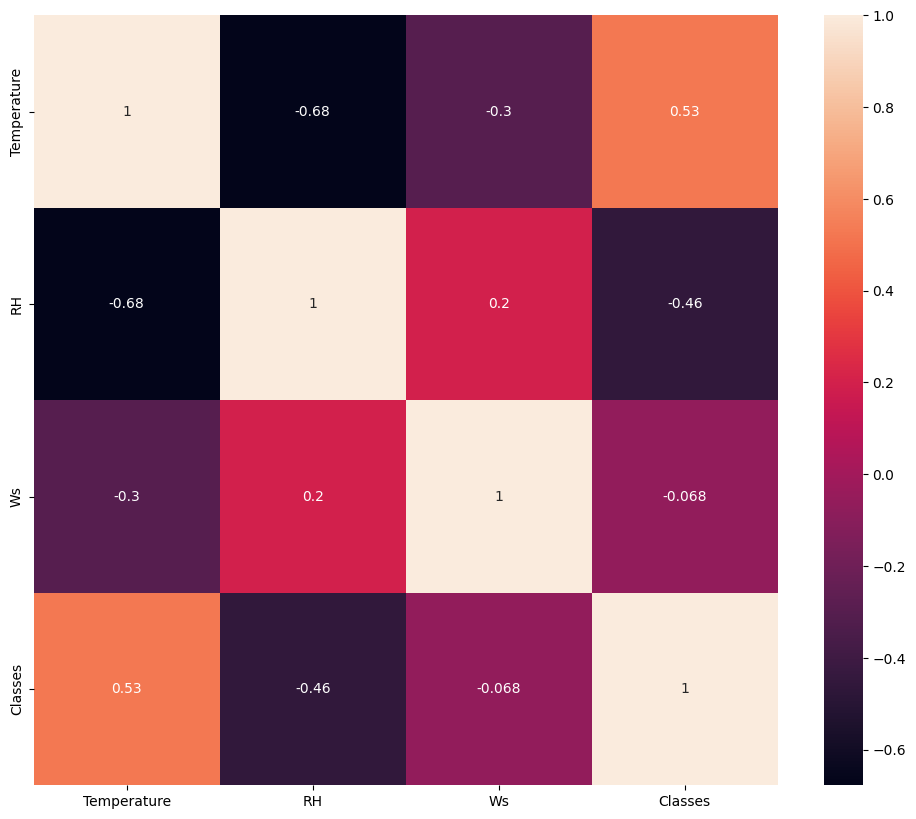

In [20]:
## Check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr(numeric_only=True)
sns.heatmap(corr,annot=True)


In [21]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [24]:
# Threshold -> Domain Expertise
def correlation(dataset, threshold):
    col_corr = set()
    
    numeric_data = dataset.select_dtypes(include=['number'])  # ✅ only numeric
    corr_matrix = numeric_data.corr()
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    
    return col_corr

In [27]:
corr_features = correlation(X_train, 0.85)

In [28]:
X_train.drop(corr_features, axis=1, inplace=True)
X_test.drop(corr_features, axis=1, inplace=True)

X_train.shape, X_test.shape

((184, 10), (62, 10))

## Feature Scaling and  Standardization

In [30]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27380\2931283843.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [32]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# align columns (important)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# now scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [34]:
X_train_scaled

array([[ 0.2196799 ,  0.71013337, -1.34321678, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.76364918, -1.8615639 ,  0.1870834 , ..., -0.07392213,
        -0.07392213, -0.07392213],
       [-0.86825865,  1.17172006, -0.57806669, ..., -0.07392213,
        -0.07392213, -0.07392213],
       ...,
       [-1.95619721,  0.90795623,  0.56965845, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.76364918, -0.27898097, -2.10836686, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [-0.59627402,  0.97389719,  2.09995862, ..., -0.07392213,
        -0.07392213, -0.07392213]], shape=(184, 711))

In [35]:
X_test_scaled

array([[ 0.2196799 ,  1.03983815,  0.56965845, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.2196799 , -0.54274479, -0.96064173, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.2196799 , -0.34492192,  0.1870834 , ..., -0.07392213,
        -0.07392213, -0.07392213],
       ...,
       [ 0.49166454, -1.33403626, -0.19549164, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 1.03563382, -0.47680383, -0.96064173, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 1.03563382, -0.47680383,  0.95223349, ..., -0.07392213,
        -0.07392213, -0.07392213]], shape=(62, 711))

## Box Plot to understand effect of Standard Scaler

In [37]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

([0, 1, 2, 3],
 [Text(0, 0, 'Temperature'),
  Text(1, 0, 'RH'),
  Text(2, 0, 'Ws'),
  Text(3, 0, 'Classes')])

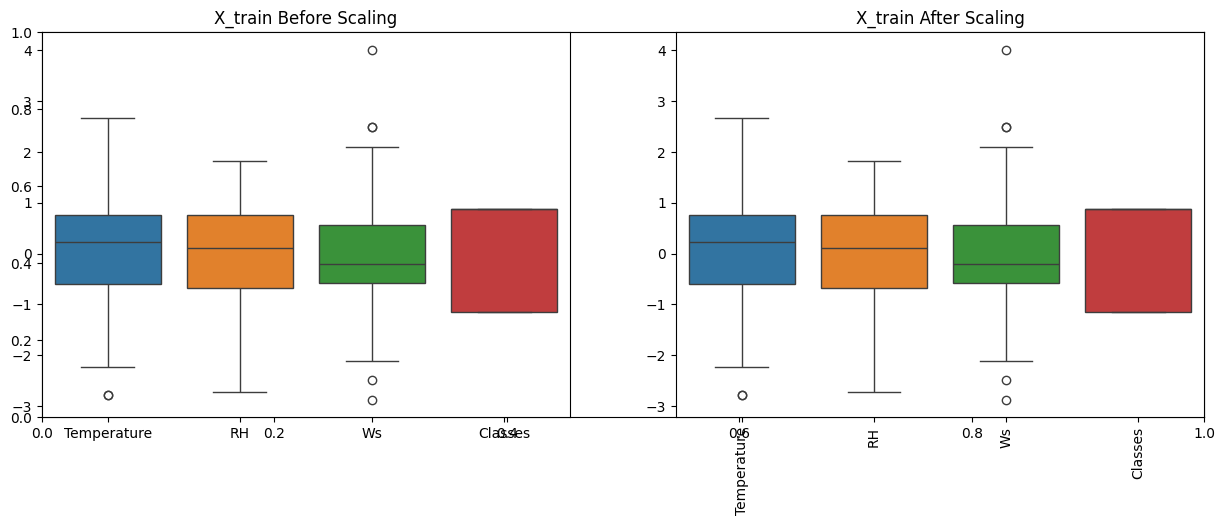

In [39]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

plt.subplots(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=X_train[num_cols])
plt.title('X_train Before Scaling')

plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled[num_cols])
plt.title('X_train After Scaling')

plt.xticks(rotation=90)

<Axes: >

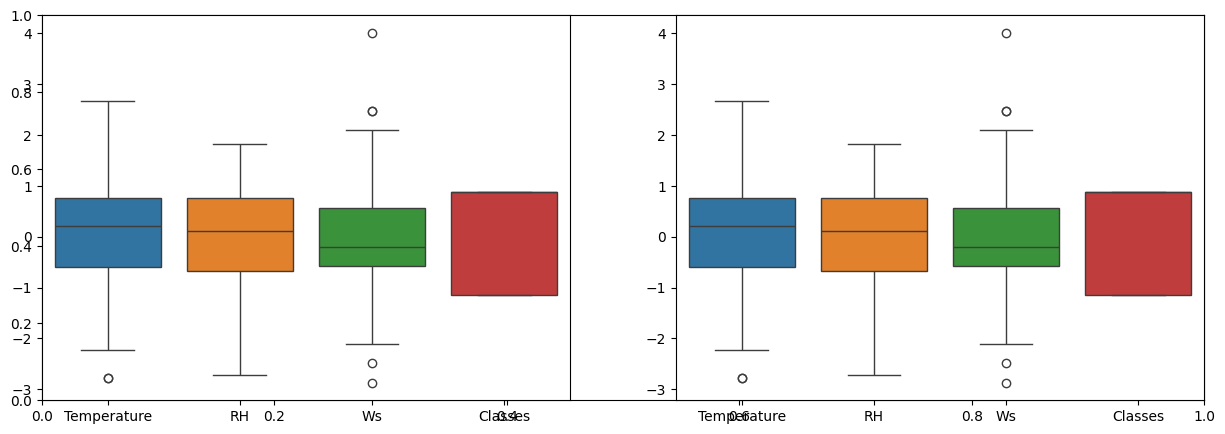

In [40]:
cols = num_cols[:6]   # pick top 5–6 features

plt.subplots(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=X_train[cols])

plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled[cols])

## Linear Regression Model

In [43]:
X_train_scaled = X_train_scaled.dropna()
y_train = y_train.loc[X_train_scaled.index]

KeyError: '[6, 9, 10, 15, 16, 18, 19, 24, 25, 30, 33, 38, 45, 55, 60, 66, 67, 68, 75, 79, 82, 86, 96, 97, 104, 109, 112, 117, 118, 119, 120, 132, 147, 153, 154, 155, 156, 165, 170, 173, 178, 181, 182, 183] not in index'

In [47]:
X_train.isnull().sum().sort_values(ascending=False).head(10)

Temperature    2
RH             2
Ws             2
Classes        0
Rain_0.1       0
Rain_0.2       0
Rain_0.3       0
Rain_0.4       0
Rain_0.5       0
Rain_0.6       0
dtype: int64

In [48]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [50]:
import numpy as np

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

In [51]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [56]:
import pandas as pd

data = X_train.copy()
data["target"] = y_train

data = data.dropna()

X_train_clean = data.drop("target", axis=1)
y_train_clean = data["target"]

In [57]:
test_data = X_test.copy()
test_data["target"] = y_test

test_data = test_data.dropna()

X_test_clean = test_data.drop("target", axis=1)
y_test_clean = test_data["target"]

In [60]:
LabelEncoder().fit_transform(y_train_clean)

array([  3,  16,   1, 104,  37,  10,   7,  27,  87,  58,  14,   1,  28,
         2,   7,  60,  56,  40,   3,   3,  94,  89,  67,   9,  79,   8,
         3,   2,  92,  75,  71, 105,  74,   0,  87,  86,  58,   5,   4,
        49,  81,   9,  90,  23,  42,   8,  38,  32,  69,   8,   4,   5,
         1,  36,  72,   2,   2,  91,  43,  81,  59,  29,  56,   6,  70,
        83,   9,  90,   3,  93,  68,  33,  75,   5,   5,   4,  64,   6,
         8,  28,   9,  70,  31,  21,  46,  75,   5,  38,  54,  96,  35,
        70,  48,   5,  47,  88,   0,  63,  68,   8,  11,  34,   0,   1,
        12,  13,  57,   8,  15,  80,  12,  45,  83,  85,  93, 101, 103,
         3,  61,   7,  73,  77,   3,   4,  18,  65,   8,   2,  82,  81,
         0,  44,  62,  11,   8,  95,   8,  99, 100,  76,  25,  26,   0,
         8,  95,  22,  19,  52,  55,  20,  97,  84,  39,  51,   6,  69,
        98, 104,  50,   4,  53, 102,  88,  48,   5,   4,   1,  30,  66,
        17,  41,  78,   1,   5,  54,  60,  24,   0,   1,   1,  1

In [61]:
print(y_train.unique())

<StringArray>
[ '0.3', '10.5',  '0.1',  '9.9', '14.8',    '1',  '0.7', '12.7',  '5.9',
  '2.8',
 ...
    '8', '19.3',  '2.1',  '9.5', '13.2', '26.3', '10.6',   '16', '30.3',
 '12.1']
Length: 108, dtype: str


In [62]:
import pandas as pd

y_train_clean = pd.to_numeric(y_train, errors='coerce')
y_test_clean = pd.to_numeric(y_test, errors='coerce')

In [63]:
train_mask = ~y_train_clean.isna()
test_mask = ~y_test_clean.isna()

X_train_final = X_train_clean[train_mask]
y_train_final = y_train_clean[train_mask]

X_test_final = X_test_clean[test_mask]
y_test_final = y_test_clean[test_mask]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27380\3471684102.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train_final = X_train_clean[train_mask]


In [64]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train_final, y_train_final)

y_pred = linreg.predict(X_test_final)

MAE: 2.497973284131308
R2: 0.7553347278649831


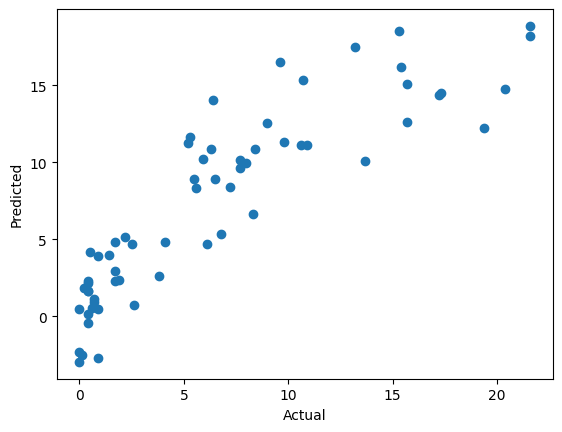

In [65]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

print("MAE:", mean_absolute_error(y_test_final, y_pred))
print("R2:", r2_score(y_test_final, y_pred))

plt.scatter(y_test_final, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## Lasso Regression

In [68]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [71]:
import numpy as np
import pandas as pd

In [72]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [73]:
print(np.isnan(X_train_imputed).sum())  # MUST be 0
print(np.isnan(X_test_imputed).sum())    # MUST be 0

0
0


In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [76]:
X_train_scaled

array([[ 0.22088363,  0.71402454, -1.35057692, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.76783359, -1.87176433,  0.18810852, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [-0.87301627,  1.17814049, -0.5812342 , ..., -0.07392213,
        -0.07392213, -0.07392213],
       ...,
       [-1.96691618,  0.91293137,  0.57277988, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.76783359, -0.28050964, -2.11991965, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [-0.59954129,  0.97923365,  2.11146533, ..., -0.07392213,
        -0.07392213, -0.07392213]], shape=(184, 711))

In [77]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [78]:
print(np.isnan(X_train_imputed).sum())
print(np.isnan(X_test_imputed).sum())

0
0


In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled_new = scaler.fit_transform(X_train_imputed)
X_test_scaled_new = scaler.transform(X_test_imputed)

In [81]:
X_train

,Temperature,RH,Ws,Classes,Rain_0.1,Rain_0.2,Rain_0.3,Rain_0.4,Rain_0.5,Rain_0.6,...,BUI_8.3,BUI_8.4,BUI_9,BUI_9.1,BUI_9.2,BUI_9.3,BUI_9.4,BUI_9.6,BUI_9.7,BUI_BUI
101,0.219680,0.710133,-1.343217,-1.140175,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
197,0.763649,-1.861564,0.187083,0.877058,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
126,-0.868259,1.171720,-0.578067,-1.140175,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
69,0.763649,-0.213040,0.569658,0.877058,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
200,2.123572,-1.399977,-2.108367,0.877058,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-2.228182,1.303602,-0.195492,-1.140175,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
14,-1.140243,1.171720,0.569658,-1.140175,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
92,-1.956197,0.907956,0.569658,-1.140175,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
179,0.763649,-0.278981,-2.108367,-1.140175,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [82]:
X_train_scaled
X_train_scaled_new

array([[ 0.22088363,  0.71402454, -1.35057692, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.76783359, -1.87176433,  0.18810852, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [-0.87301627,  1.17814049, -0.5812342 , ..., -0.07392213,
        -0.07392213, -0.07392213],
       ...,
       [-1.96691618,  0.91293137,  0.57277988, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.76783359, -0.28050964, -2.11991965, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [-0.59954129,  0.97923365,  2.11146533, ..., -0.07392213,
        -0.07392213, -0.07392213]], shape=(184, 711))

In [83]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

6
0


In [84]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

In [85]:
import numpy as np

print(np.isnan(X_train_clean).sum())
print(np.isnan(X_test_clean).sum())

0
0


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final = scaler.fit_transform(X_train_clean)
X_test_final = scaler.transform(X_test_clean)

In [89]:
X_train_clean


array([[ 0.2196799 ,  0.71013337, -1.34321678, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.76364918, -1.8615639 ,  0.1870834 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.86825865,  1.17172006, -0.57806669, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.95619721,  0.90795623,  0.56965845, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.76364918, -0.27898097, -2.10836686, ...,  0.        ,
         0.        ,  0.        ],
       [-0.59627402,  0.97389719,  2.09995862, ...,  0.        ,
         0.        ,  0.        ]], shape=(184, 711))

In [90]:
X_train_final

array([[ 0.22088363,  0.71402454, -1.35057692, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.76783359, -1.87176433,  0.18810852, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [-0.87301627,  1.17814049, -0.5812342 , ..., -0.07392213,
        -0.07392213, -0.07392213],
       ...,
       [-1.96691618,  0.91293137,  0.57277988, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.76783359, -0.28050964, -2.11991965, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [-0.59954129,  0.97923365,  2.11146533, ..., -0.07392213,
        -0.07392213, -0.07392213]], shape=(184, 711))

In [91]:
X_train_scaled

array([[ 0.22088363,  0.71402454, -1.35057692, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.76783359, -1.87176433,  0.18810852, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [-0.87301627,  1.17814049, -0.5812342 , ..., -0.07392213,
        -0.07392213, -0.07392213],
       ...,
       [-1.96691618,  0.91293137,  0.57277988, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [ 0.76783359, -0.28050964, -2.11991965, ..., -0.07392213,
        -0.07392213, -0.07392213],
       [-0.59954129,  0.97923365,  2.11146533, ..., -0.07392213,
        -0.07392213, -0.07392213]], shape=(184, 711))

In [92]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [93]:
imputer = SimpleImputer(strategy="mean")

X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

In [94]:
print(np.isnan(X_train_clean).sum())
print(np.isnan(X_test_clean).sum())

0
0


In [95]:
scaler = StandardScaler()

X_train_final = scaler.fit_transform(X_train_clean)
X_test_final = scaler.transform(X_test_clean)

In [96]:
print(np.isnan(X_train_final).sum())

0


In [98]:
import numpy as np

print("NaN in X_train_final:", np.isnan(X_train_final).sum())
print("Shape:", X_train_final.shape)

NaN in X_train_final: 0
Shape: (184, 711)


In [99]:
print(y_train.dtype)
print(y_train.head())

str
101     0.3
197    10.5
126     0.1
69      9.9
200    14.8
Name: FWI, dtype: str


In [100]:
print(y_train.isnull().sum())

1


In [101]:
mask = ~y_train.isnull()

X_train_final = X_train_final[mask]
y_train = y_train[mask]

In [103]:
import numpy as np

mask = ~y_train.isnull().to_numpy()

In [104]:
X_train_final = X_train_final[mask]
y_train = y_train.to_numpy()[mask]

In [109]:
import pandas as pd

df = pd.read_csv("Algerian_forest_fires_cleaned_dataset.csv")  # use your actual file name

In [112]:
X = df.drop("Classes", axis=1)
y = df["Classes"]

In [114]:
import numpy as np

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

In [115]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [116]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [117]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [119]:
print(X.isnull().sum().sum())
print(y.isnull().sum())

19
2


In [120]:
mask = ~y.isnull()
X = X[mask]
y = y[mask]

In [121]:
X = X.dropna()
y = y.loc[X.index]

In [122]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns

numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric, num_cols),
    ("cat", categorical, cat_cols)
])

model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [124]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [126]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [127]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_absolute_error

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.3839723003874099
R2: 0.33621632850463845


In [128]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [131]:
import pandas as pd

df = X.copy()
df["target"] = y

df = df.dropna()   # remove all bad rows together

In [132]:
X = df.drop("target", axis=1)
y = df["target"]

In [133]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [134]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [135]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MAE: 0.30434006938188385
R2 Score: 0.5481631325843335


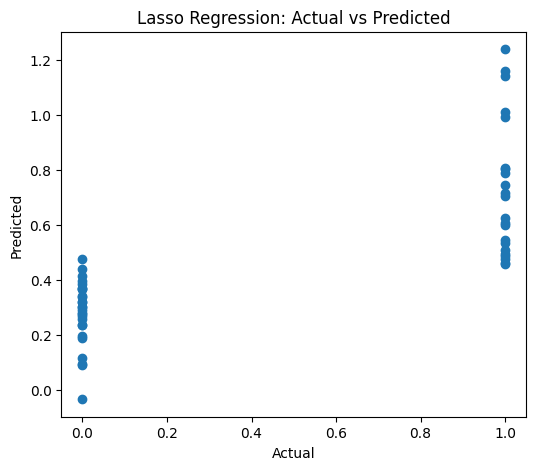

In [136]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso Regression: Actual vs Predicted")
plt.show()

MAE: 0.2650185293292357
R2: 0.629855069937834


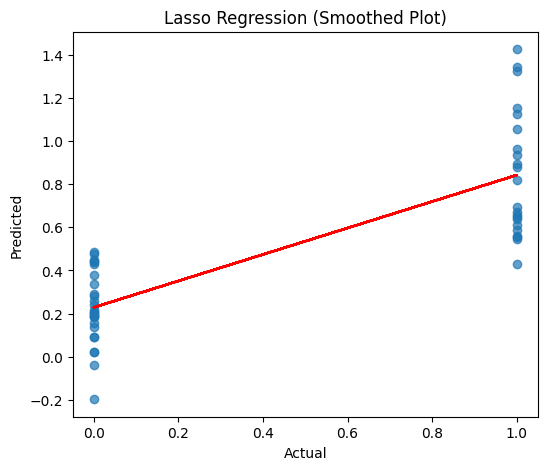

In [137]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

lasso = Lasso(alpha=0.01)   # 🔥 reduce regularization

lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# 🔥 smoother plot style (like linear regression)
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7)

# regression line (makes it look like LR plot)
import numpy as np
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)

plt.plot(y_test, p(y_test), color="red")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso Regression (Smoothed Plot)")
plt.show()

### Cross Validation Lasso

In [138]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [139]:
lassocv.alpha_

np.float64(0.008390671279884786)

In [140]:
lassocv.alphas_

array([0.38946046, 0.36321213, 0.33873285, 0.31590339, 0.29461256,
       0.27475666, 0.25623898, 0.23896933, 0.22286359, 0.20784333,
       0.19383539, 0.18077153, 0.16858814, 0.15722586, 0.14662936,
       0.13674704, 0.12753074, 0.1189356 , 0.11091974, 0.10344412,
       0.09647233, 0.08997042, 0.08390671, 0.07825168, 0.07297778,
       0.06805932, 0.06347235, 0.05919453, 0.05520501, 0.05148438,
       0.04801451, 0.04477849, 0.04176057, 0.03894605, 0.03632121,
       0.03387328, 0.03159034, 0.02946126, 0.02747567, 0.0256239 ,
       0.02389693, 0.02228636, 0.02078433, 0.01938354, 0.01807715,
       0.01685881, 0.01572259, 0.01466294, 0.0136747 , 0.01275307,
       0.01189356, 0.01109197, 0.01034441, 0.00964723, 0.00899704,
       0.00839067, 0.00782517, 0.00729778, 0.00680593, 0.00634724,
       0.00591945, 0.0055205 , 0.00514844, 0.00480145, 0.00447785,
       0.00417606, 0.0038946 , 0.00363212, 0.00338733, 0.00315903,
       0.00294613, 0.00274757, 0.00256239, 0.00238969, 0.00222

In [141]:
lassocv.mse_path_

array([[0.23869367, 0.23631929, 0.26594733, 0.23778009, 0.25186858],
       [0.21985749, 0.22402015, 0.26594733, 0.21693935, 0.23588607],
       [0.20206989, 0.21318318, 0.23732745, 0.1999435 , 0.21666442],
       [0.18656659, 0.20362738, 0.21558398, 0.18481667, 0.19985665],
       [0.17245805, 0.19519463, 0.1963975 , 0.17091855, 0.18515084],
       [0.15889959, 0.18774688, 0.17973067, 0.15894161, 0.17228065],
       [0.14701966, 0.18116345, 0.16525283, 0.14862963, 0.16101045],
       [0.13672034, 0.17454279, 0.15267629, 0.13956947, 0.15113919],
       [0.12779349, 0.16628368, 0.14175499, 0.13130824, 0.14248826],
       [0.12005827, 0.15895031, 0.1322709 , 0.12427695, 0.13490174],
       [0.11335752, 0.15247335, 0.12403582, 0.1183045 , 0.12824783],
       [0.10755467, 0.14678245, 0.11688615, 0.11324431, 0.1220744 ],
       [0.10253112, 0.14177997, 0.11067846, 0.10896754, 0.11640085],
       [0.09818371, 0.13737863, 0.10529168, 0.10536471, 0.11140196],
       [0.094423  , 0.1335047 , 0.

Mean absolute error 0.2631895928871164
R2 Score 0.6329882473299335


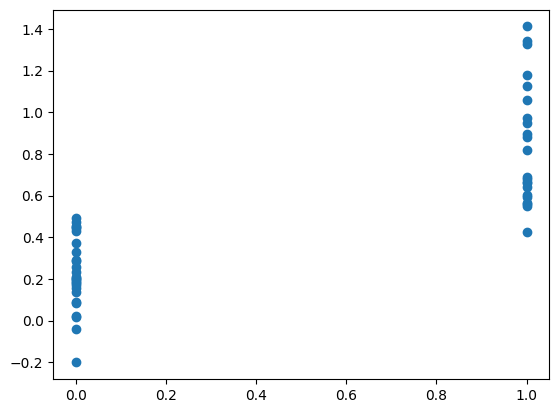

In [142]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

##  Ridge Resgreesion Model

Mean absolute error 0.2539866009719567
R2 Score 0.6497431520524577


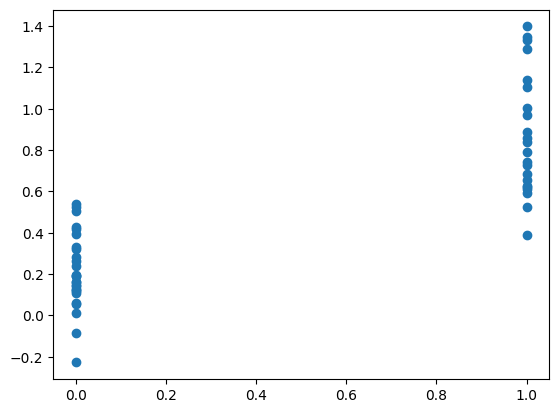

In [143]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

### Ridge CV

Mean absolute error 0.2539866009719567
R2 Score 0.6497431520524577


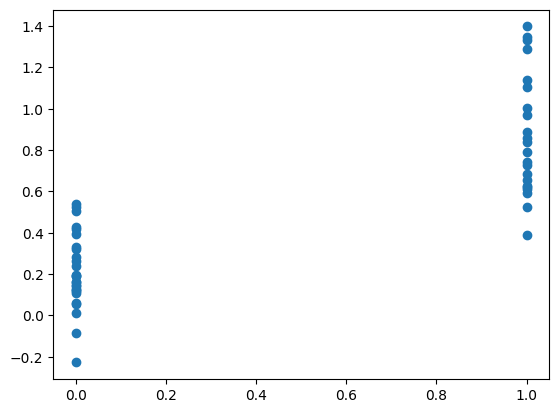

In [144]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 0.2539866009719567
R2 Score 0.6497431520524577


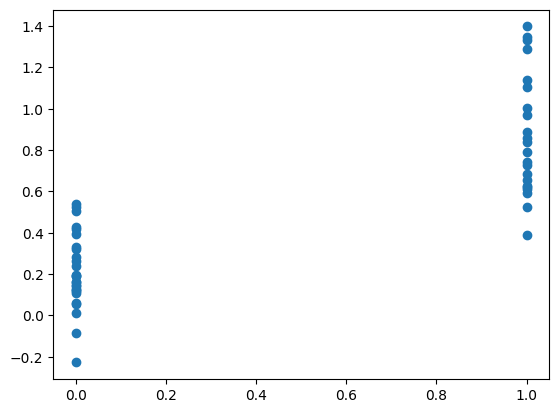

In [145]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [146]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

### ElasticNet Regression

Mean absolute error 0.49316221333894383
R2 Score -0.001033468564556106


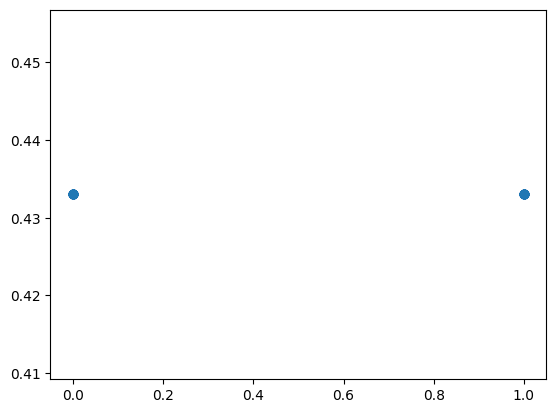

In [147]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

## ElasticNet CV

Mean absolute error 0.2627883079256652
R2 Score 0.6342349249354832


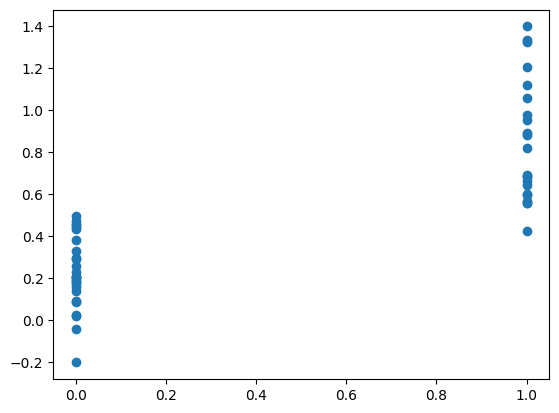

In [148]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [149]:
elasticcv.alphas_

array([0.77892092, 0.72642426, 0.6774657 , 0.63180677, 0.58922511,
       0.54951331, 0.51247795, 0.47793866, 0.44572719, 0.41568667,
       0.38767078, 0.36154307, 0.33717627, 0.31445172, 0.29325873,
       0.27349407, 0.25506149, 0.23787119, 0.22183947, 0.20688823,
       0.19294466, 0.17994084, 0.16781343, 0.15650336, 0.14595556,
       0.13611864, 0.1269447 , 0.11838905, 0.11041003, 0.10296876,
       0.09602901, 0.08955698, 0.08352114, 0.07789209, 0.07264243,
       0.06774657, 0.06318068, 0.05892251, 0.05495133, 0.0512478 ,
       0.04779387, 0.04457272, 0.04156867, 0.03876708, 0.03615431,
       0.03371763, 0.03144517, 0.02932587, 0.02734941, 0.02550615,
       0.02378712, 0.02218395, 0.02068882, 0.01929447, 0.01799408,
       0.01678134, 0.01565034, 0.01459556, 0.01361186, 0.01269447,
       0.01183891, 0.011041  , 0.01029688, 0.0096029 , 0.0089557 ,
       0.00835211, 0.00778921, 0.00726424, 0.00677466, 0.00631807,
       0.00589225, 0.00549513, 0.00512478, 0.00477939, 0.00445